In [20]:
! pip install igraph
! pip install reinmax

In [21]:
import os
import time
import copy
import math
import random
import typing
import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph as ig

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torch.distributions import MultivariateNormal

from sklearn.metrics import roc_auc_score
from reinmax import reinmax

# ==========================================
# Configuration & Seeds
# ==========================================

def set_random_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

CONFIG = {
    'seed': 0,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'gpu_index': "3",
    'num_nodes': 20,
    'edge_num': 30,
    'n_samples': 10000,
    'batch_size': 256,
    'n_epochs': 5000,
    'lr': 1e-3,
    'eps': 1e-5,
    'embed_dim': 512,
    'n_layer': 1,
    'sigma': 25.0
}

# Set device
if torch.cuda.is_available():
    os.environ['CUDA_VISIBLE_DEVICES'] = CONFIG['gpu_index']
    torch.set_default_dtype(torch.float32)

set_random_seed(CONFIG['seed'])
device = CONFIG['device']
print(f"Running on {device}")


Running on cuda


In [22]:
# ==========================================
# DAG Utils
# ==========================================

def is_dag(W: np.ndarray) -> bool:
    """Returns ``True`` if ``W`` is a DAG, ``False`` otherwise."""
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    return G.is_dag()

def simulate_dag(d: int, s0: int, graph_type: str) -> np.ndarray:
    """Simulate random DAG with some expected number of edges."""
    def _random_permutation(M):
        P = np.random.permutation(np.eye(M.shape[0]))
        return P.T @ M @ P

    def _random_acyclic_orientation(B_und):
        return np.tril(_random_permutation(B_und), k=-1)

    def _graph_to_adjmat(G):
        return np.array(G.get_adjacency().data)

    if graph_type == 'ER':
        G_und = ig.Graph.Erdos_Renyi(n=d, m=s0)
        B_und = _graph_to_adjmat(G_und)
        B = _random_acyclic_orientation(B_und)
    elif graph_type == 'SF':
        G = ig.Graph.Barabasi(n=d, m=int(round(s0 / d)), directed=True)
        B = _graph_to_adjmat(G)
    elif graph_type == 'BP':
        top = int(0.2 * d)
        G = ig.Graph.Random_Bipartite(top, d - top, m=s0, directed=True, neimode=ig.OUT)
        B = _graph_to_adjmat(G)
    elif graph_type == 'Fully':
        B = np.triu(np.ones((d, d)), 1)
    else:
        raise ValueError('unknown graph type')

    B_perm = _random_permutation(B)
    assert ig.Graph.Adjacency(B_perm.tolist()).is_dag()
    return B_perm

def simulate_linear_sem(W: np.ndarray, n: int, sem_type: str, noise_scale: typing.Optional[typing.Union[float, typing.List[float]]] = None) -> np.ndarray:
    """Simulate samples from linear SEM."""
    from scipy.special import expit as sigmoid

    def _simulate_single_equation(X, w, scale):
        if sem_type == 'gauss':
            z = np.random.normal(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'exp':
            z = np.random.exponential(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'gumbel':
            z = np.random.gumbel(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'uniform':
            z = np.random.uniform(low=-scale, high=scale, size=n)
            x = X @ w + z
        elif sem_type == 'logistic':
            x = np.random.binomial(1, sigmoid(X @ w)) * 1.0
        elif sem_type == 'poisson':
            x = np.random.poisson(np.exp(X @ w)) * 1.0
        else:
            raise ValueError('unknown sem type')
        return x

    d = W.shape[0]
    if noise_scale is None:
        scale_vec = np.ones(d)
    elif np.isscalar(noise_scale):
        scale_vec = noise_scale * np.ones(d)
    else:
        scale_vec = noise_scale

    if not is_dag(W):
        raise ValueError('W must be a DAG')

    if np.isinf(n):
        if sem_type == 'gauss':
            X = np.sqrt(d) * np.diag(scale_vec) @ np.linalg.inv(np.eye(d) - W)
            return X
        else:
            raise ValueError('population risk not available')

    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    X = np.zeros([n, d])
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], W[parents, j], scale_vec[j])
    return X

def simulate_nonlinear_sem(B: np.ndarray, n: int, sem_type: str, noise_scale: typing.Optional[typing.Union[float, typing.List[float]]] = None) -> np.ndarray:
    """Simulate samples from nonlinear SEM."""
    from scipy.special import expit as sigmoid

    def _simulate_single_equation(X, scale):
        z = np.random.normal(scale=scale, size=n)
        pa_size = X.shape[1]
        if pa_size == 0:
            return z
        if sem_type == 'mlp':
            hidden = 100
            W1 = np.random.uniform(low=0.5, high=2.0, size=[pa_size, hidden])
            W1[np.random.rand(*W1.shape) < 0.5] *= -1
            W2 = np.random.uniform(low=0.5, high=2.0, size=hidden)
            W2[np.random.rand(hidden) < 0.5] *= -1
            x = sigmoid(X @ W1) @ W2 + z
        elif sem_type == 'mim':
            w1 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w1[np.random.rand(pa_size) < 0.5] *= -1
            w2 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w2[np.random.rand(pa_size) < 0.5] *= -1
            w3 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w3[np.random.rand(pa_size) < 0.5] *= -1
            x = np.tanh(X @ w1) + np.cos(X @ w2) + np.sin(X @ w3) + z
        else:
             raise ValueError('unknown sem type')
        return x

    d = B.shape[0]
    scale_vec = noise_scale if noise_scale else np.ones(d)
    X = np.zeros([n, d])
    G = ig.Graph.Adjacency(B.tolist())
    ordered_vertices = G.topological_sorting()
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], scale_vec[j])
    return X


In [23]:
# ==========================================
# Dataset Classes
# ==========================================

class DAGDataset(Dataset):
    def __init__(self, node_num, edge_num, n_samples, linear, DAG_type, SEM_type, device):
        self._node_num = node_num
        self._edge_num = edge_num
        self.n_samples = n_samples
        self.DAG_type = DAG_type
        self.SEM_type = SEM_type
        self.device = device
        self._graph_adj = simulate_dag(node_num, edge_num, DAG_type)
        if linear:
            self.data = simulate_linear_sem(self._graph_adj, n_samples, SEM_type)
        else:
            self.data = simulate_nonlinear_sem(self._graph_adj, n_samples, SEM_type)

    @property
    def node_num(self):
        return self._node_num

    @property
    def edge_num(self):
        return self._edge_num

    @property
    def graph_adj(self):
        return self._graph_adj

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.data[idx, :]


In [74]:
# ==========================================
# Model Components
# ==========================================

def new_gelu(x):
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))))

class MLP(nn.Module):
    def __init__(self, n_embd, bias=False, dropout=0.0):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd, bias=bias)
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = new_gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.dense(x)

class SelfAttention(nn.Module):
    def __init__(self, n_embd=768, n_head=12, bias=True, dropout=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=bias)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=bias)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout
        self.flash = False

    def forward(self, x, att_mask=None):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)
        # print("att.shape", att.shape)
        if att_mask is not None:
            att = att * att_mask.unsqueeze(1).repeat(1,self.n_head, 1,1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class EncoderLayer(nn.Module):
    def __init__(self, n_embd=768, n_head=12, bias=True, dropout=0.0):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = SelfAttention(n_embd=n_embd, n_head=n_head, bias=bias, dropout=dropout)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd=n_embd, dropout=dropout)

    def forward(self, x, att_mask=None):
        out = self.attn(self.ln_1(x), att_mask=att_mask)
        x = x + out
        x = x + self.mlp(self.ln_2(x))
        return x

class TimeAwareResBlock(nn.Module):
    def __init__(self, embed_dim, t_emb_out_dim=None):
        super().__init__()
        self.layer = Dense(embed_dim, embed_dim)
        self.act = nn.SiLU(inplace=True)
        self.ln = nn.LayerNorm(embed_dim)
        self.t_emb = Dense(embed_dim, t_emb_out_dim if t_emb_out_dim else embed_dim)

    def forward(self, x, t_embed):
        x_res = x
        t_proj = self.t_emb(t_embed)[:, None, :]
        x = self.layer(x + t_proj)
        x = self.act(x) + x_res
        return self.ln(x)

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class TimeMaskGenerator(nn.Module):
    """
    Generate attention mask logits from time t.
    Output shape: (B, T, T, 2) logits for [block, allow] (or vice versa, you decide).
    Uses low-rank symmetric factorization + diagonal to stay stable.
    """
    def __init__(self, T, t_embed_dim=128, hidden=256, rank=32, tau_init=1.0):
        super().__init__()
        self.T = T
        self.rank = rank

        # simple t->embedding (you can swap with your GaussianFourierProjection)
        self.t_mlp = nn.Sequential(
            nn.Linear(1, t_embed_dim),
            nn.SiLU(),
            nn.Linear(t_embed_dim, hidden),
            nn.SiLU(),
        )

        # produce low-rank factors and diagonal logits
        self.to_U = nn.Linear(hidden, T * rank)     # U: (B,T,r)
        self.to_d = nn.Linear(hidden, T)            # diag: (B,T)

        # global strength (learnable) and temperature
        self.scale = nn.Parameter(torch.tensor(1.0))
        self.tau = nn.Parameter(torch.tensor(tau_init))

        # optional: a learnable base matrix (shared across t) in low-rank form
        self.base_U = nn.Parameter(torch.zeros(T, rank))
        self.base_d = nn.Parameter(torch.zeros(T))

    def forward(self, t):
        """
        t: (B,) or (B,1)
        returns logits: (B,T,T,2)
        """
        if t.dim() == 1:
            t_in = t[:, None]
        else:
            t_in = t
        # print(t_in.shape)
        h = self.t_mlp(t_in.float())  # (B,hidden)
        # print(h.shape)

        U = self.to_U(h).view(-1, self.T, self.rank)          # (B,T,r)
        d = self.to_d(h).view(-1, self.T)                     # (B,T)
        # print(U.shape)
        # print(d.shape)
        # add shared base
        U = U + self.base_U[None, :, :]
        d = d + self.base_d[None, :]
        ########这边要仔细看看
        # symmetric low-rank matrix: A = U U^T
        A = torch.matmul(U, U.transpose(-1, -2))              # (B,T,T)

        # # add diagonal
        # A = A + torch.diag_embed(d)                           # (B,T,T)

        # control sharpness with scale & tau
        A = (self.scale * A) / (F.softplus(self.tau) + 1e-6)

        # convert to 2-class logits.
        # Let "allow" logit = A, "block" logit = 0 (baseline)
        logits = torch.stack([torch.zeros_like(A), A], dim=-1)  # (B,T,T,2)
        return logits

class GraphLDiffusion(nn.Module):
    def __init__(self, input_size, embed_dim=256, n_layer=8, mask_rank=32):
        super().__init__()
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
                                   nn.Linear(embed_dim, embed_dim))
        self.denses = nn.ModuleList([Dense(embed_dim, embed_dim) for _ in range(n_layer)])
        self.target_embed = nn.Embedding(input_size, embed_dim)

        self.EncoderLayers = nn.ModuleList(
            [EncoderLayer(n_embd=embed_dim, n_head=32, bias=False, dropout=0.0) for _ in range(n_layer)])

        self.ln = nn.LayerNorm(embed_dim, bias=True)

        # Initial blocks (a, b, c, d)
        self.initial_blocks = nn.ModuleList([TimeAwareResBlock(embed_dim) for _ in range(4)])

        # Final blocks (a, b, c)
        self.final_blocks = nn.ModuleList([
            TimeAwareResBlock(embed_dim),
            TimeAwareResBlock(embed_dim),
            TimeAwareResBlock(embed_dim, t_emb_out_dim=1)
        ])
        self.mask_gen = TimeMaskGenerator(
            T=input_size,
            t_embed_dim=128,
            hidden=256,
            rank=mask_rank,
            tau_init=1.0
        )
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))


        self.act = lambda x: x * torch.sigmoid(x)
        self.att_mask_pro = nn.Parameter(torch.ones(input_size, input_size, 2))
        self.x_layer_weight = nn.Parameter(torch.ones(n_layer))


    def forward(self, x, t, targets=None):
        embed = self.act(self.embed(t))
        # print(t.shape)
        x = (x[:, :, None] * self.target_embed.weight[None, :, :])

        for block in self.initial_blocks:
            x = block(x, embed)

        # Generate mask logits from t
        att_mask_logits = self.mask_gen(t)  # (B,T,T,2)
        # print(att_mask_logits.shape)

        # Reinmax to sample / harden
        attn_mask_hard, _ = reinmax(att_mask_logits.reshape(-1, 2), tau=1)
        attn_mask_hard = attn_mask_hard.reshape(att_mask_logits.shape)
        attn_mask = attn_mask_hard[..., 1] # (B,T,T)
        # print(attn_mask.shape)

        x_list = []
        for enc_layer, dense in zip(self.EncoderLayers, self.denses):
            x = enc_layer(x + dense(embed)[:, None, :], att_mask=attn_mask)
            x_list.append(x)

        x = torch.stack(x_list, dim=0)
        x = torch.sum(x * self.x_layer_weight[:, None, None, None], dim=0)
        x = self.ln(x)

        for block in self.final_blocks:
            x = block(x, embed)

        out = x[:, :, 0]
        return out, attn_mask

In [75]:
# ==========================================
# Diffusion Utils
# ==========================================

def marginal_prob_std(t, sigma):
    return torch.sqrt((sigma ** (2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
    return torch.tensor(sigma ** t, device=device)

marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=CONFIG['sigma'])


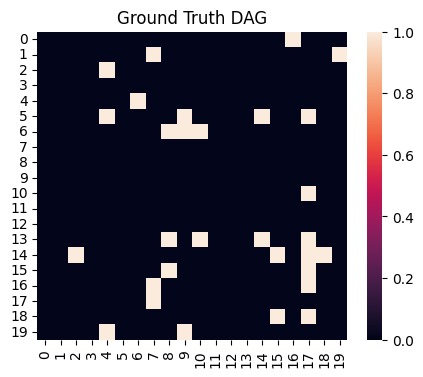

In [76]:
# ==========================================
# Training
# ==========================================

# Prepare Data
dataset = DAGDataset(
    node_num=CONFIG['num_nodes'],
    edge_num=CONFIG['edge_num'],
    n_samples=CONFIG['n_samples'],
    linear=False,
    DAG_type='ER',
    SEM_type='mlp',
    device=CONFIG['device']
)
data_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)

# Plot Ground Truth
plt.figure(figsize=(5, 4))
sns.heatmap(dataset.graph_adj)
plt.title("Ground Truth DAG")
plt.show()

Starting training...
Epoch 0 | AUC: 0.540762 | Score Loss: 1.156025


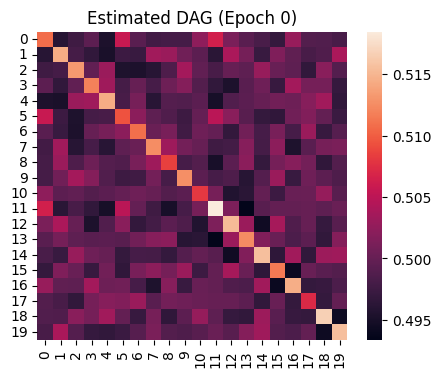

Epoch 10 | AUC: 0.547143 | Score Loss: 0.704288
Epoch 20 | AUC: 0.547143 | Score Loss: 0.650497


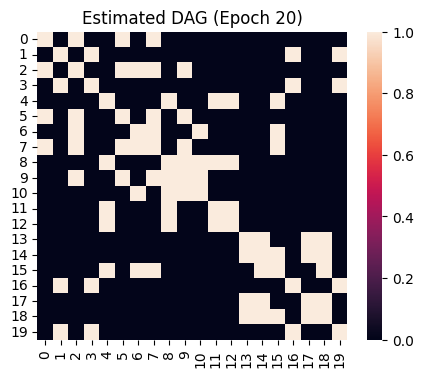

Epoch 30 | AUC: 0.547143 | Score Loss: 0.637288
Epoch 40 | AUC: 0.547143 | Score Loss: 0.639378


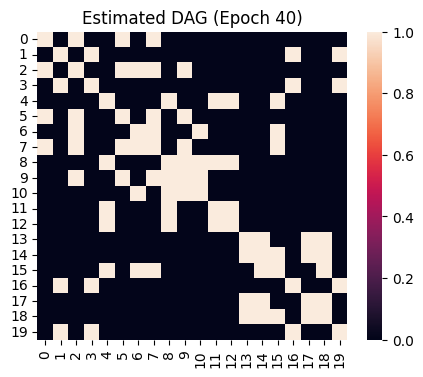

Epoch 50 | AUC: 0.547143 | Score Loss: 0.640555


KeyboardInterrupt: 

In [78]:
# Initialize Model
score_model = GraphLDiffusion(CONFIG['num_nodes'], embed_dim=CONFIG['embed_dim'], n_layer=CONFIG['n_layer'])
score_model = score_model.to(device)
optimizer = Adam(score_model.parameters(), lr=CONFIG['lr'])
# Metrics
score_loss_arr = []
mask_array = []

print("Starting training...")
for epoch in range(CONFIG['n_epochs']):
    for x in data_loader:
        x = x.to(device)
        random_t = torch.rand(x.shape[0], device=x.device) * (1. - CONFIG['eps']) + CONFIG['eps']
        random_t = random_t * 0.5
        z = torch.randn_like(x)
        std = marginal_prob_std_fn(random_t)
        perturbed_x = x + z * std[:, None]

        score, attn_mask = score_model(perturbed_x.float(), random_t)

        loss_score = torch.mean(torch.sum((score * std[:, None] + z) ** 2, dim=(1)) / score.shape[1])
        loss_sparsity = torch.sum(torch.abs(attn_mask)) * 0.0001
        loss_all = loss_score + loss_sparsity

        score_loss_arr.append(loss_score.item())

        optimizer.zero_grad()
        loss_all.backward()
        optimizer.step()

    if epoch % 10 == 0:
        att_mask_logits = score_model.mask_gen.forward(torch.ones((1,)).cuda()*0.5)  # (B,T,T,2)
        # print(att_mask_logits.shape)

        # Reinmax to sample / harden
        mask_hard, mask_soft = reinmax(att_mask_logits, tau=1)
        # attn_mask_hard = attn_mask_hard.reshape(att_mask_logits.shape)
        # attn_mask = attn_mask_hard[..., 1] # (B,T,T)
        # mask_hard, mask_soft = reinmax(score_model.att_mask_pro, tau=1)
        mask = mask_soft[..., 1].detach().cpu()[0]
        mask_array.append(mask)

        # Calculate AUC on off-diagonal elements
        index_no_d_auc = torch.eye(mask.size(0)) == 0
        off_diagonal_pred = mask[index_no_d_auc]
        off_diagonal_true = dataset.graph_adj[index_no_d_auc.numpy().astype(bool)].flatten()

        auc = roc_auc_score(off_diagonal_true, off_diagonal_pred.flatten())
        mean_score_loss = np.mean(score_loss_arr[-len(data_loader):]) # Mean of last epoch

        print(f'Epoch {epoch} | AUC: {auc:.6f} | Score Loss: {mean_score_loss:.6f}')

        # Visualization
        if epoch % 20 == 0:
             plt.figure(figsize=(5, 4))
             sns.heatmap(mask)
             plt.title(f"Estimated DAG (Epoch {epoch})")
             plt.show()


In [79]:
mask_soft

tensor([[[[0.0000e+00, 1.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [0.0000e+00, 1.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [0.0000e+00, 1.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [0.0000e+00, 1.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 1.8857e-19],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 2.0974e-31],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 3.1876e-13],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00]],

         [[1.0000e+00, 0.0000e+00],
          [0.0000e+00, 1.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [0.0000e+00, 1.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0000e+00],
          [1.0000e+00, 0.0

In [80]:
att_mask_logits

tensor([[[[    0.0000,  1765.5503],
          [    0.0000,  -837.6973],
          [    0.0000,  1340.1852],
          [    0.0000,  -180.9738],
          [    0.0000,  -126.1069],
          [    0.0000,   964.9517],
          [    0.0000,  -454.9122],
          [    0.0000,  1337.8921],
          [    0.0000,  -562.8481],
          [    0.0000,   -43.1148],
          [    0.0000,  -637.3961],
          [    0.0000,  -359.5284],
          [    0.0000,  -486.0143],
          [    0.0000,   -70.6395],
          [    0.0000,  -265.0602],
          [    0.0000,  -360.5815],
          [    0.0000,  -383.5011],
          [    0.0000,   -28.7743],
          [    0.0000,  -160.6067],
          [    0.0000,  -212.1499]],

         [[    0.0000,  -837.6973],
          [    0.0000,  2760.2476],
          [    0.0000,  -680.7744],
          [    0.0000,  2241.1567],
          [    0.0000,  -848.0416],
          [    0.0000,  -341.2371],
          [    0.0000,  -656.0463],
          [    0.0000, -10